# Tidal Flow Stuff

## Import Landlab + Components + others

In [1]:
# landlab imports
from landlab import RasterModelGrid, imshow_grid
from landlab.components import TidalFlowCalculator
from landlab.plot.graph import plot_graph
from landlab.grid.mappers import map_link_vector_components_to_node

# bmi imports
from bmi_topography import Topography

# other imports
import numpy as np
import matplotlib.pyplot as plt

## Import Real Elevation Data and Create a Grid

Documentation for bmi-topography can be found at https://bmi-topography.csdms.io/en/latest/#api-key

Values for your south, north, west, and east values can be calculated at https://mapscaping.com/bounding-box-calculator/ 

To access OpenTopography's elevation data, you will need to create an API key. Information for how to do this can be found at: https://opentopography.org/blog/introducing-api-keys-access-opentopography-global-datasets

In [2]:
# Import elevation data from OpenTopography -- this example is of Hog Island, VA
barrier_island_dem = Topography(
    dem_type = "SRTM15Plus", 
    south = 37.362517, 
    north = 37.473768, 
    west = -75.761307, 
    east = -75.623978,
    api_key = '1b2170146e1f0fc9f60dadaf1447fe64')

barrier_island = barrier_island_dem.load()
barrier_island.values.shape

"""
Example Topographies:

Gulf of Uraba, Colombia
-----------------------
    south = 7.895485, 
    north = 8.179684,
    west = -76.954559,
    east = -76.696381,

Hog Island, VA
-----------------------
    south = 37.362517, 
    north = 37.473768, 
    west = -75.761307, 
    east = -75.623978, 
"""

'\nExample Topographies:\n\nGulf of Uraba, Colombia\n-----------------------\n    south = 7.895485, \n    north = 8.179684,\n    west = -76.954559,\n    east = -76.696381,\n\nHog Island, VA\n-----------------------\n    south = 37.362517, \n    north = 37.473768, \n    west = -75.761307, \n    east = -75.623978, \n'

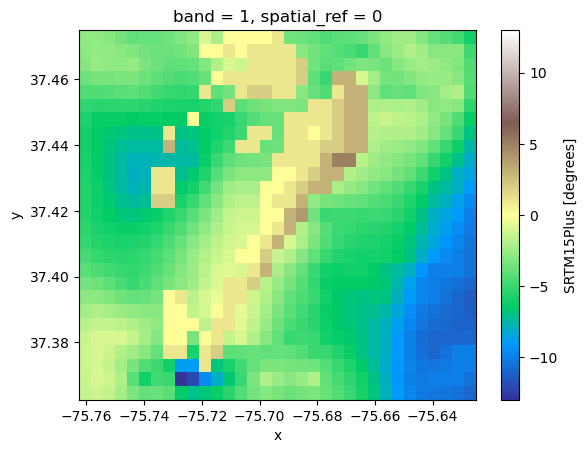

In [3]:
# Plot elevation as a check
import matplotlib.pyplot as plt
barrier_island_dem.da.plot(cmap="terrain")
plt.show()

RasterModelGrid() takes the parameter, xy_spacing, this is the resolution of your elevation data (SRTMGL3: 90 x 90 m, SRTM15Plus: 500 x 500 m, etc.)

In [4]:
# Input elevation data into grid
z = np.flipud(barrier_island.values.squeeze())
z = z.astype(float)
grid = RasterModelGrid(z.shape, xy_spacing=(500.0, 500.0))
grid.at_node["topographic__elevation"] = z

In [5]:
# set the tidal boundarys, where you want the water to come from
grid.set_closed_boundaries_at_grid_edges(False, True, True, True) # may need to change with input elevation

"""
Example Topographies:

grid.set_closed_boundaries_at_grid_edges(East, North, West, South)

Gulf of Uraba, Colombia
-----------------------
grid.set_closed_boundaries_at_grid_edges(True, False, True, True)

Hog Island, VA
-----------------------
grid.set_closed_boundaries_at_grid_edges(False, True, True, True)

"""

'\nExample Topographies:\n\ngrid.set_closed_boundaries_at_grid_edges(East, North, West, South)\n\nGulf of Uraba, Colombia\n-----------------------\ngrid.set_closed_boundaries_at_grid_edges(True, False, True, True)\n\nHog Island, VA\n-----------------------\ngrid.set_closed_boundaries_at_grid_edges(False, True, True, True)\n\n'

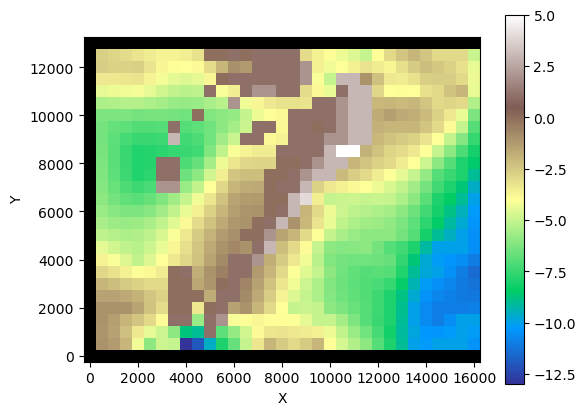

In [6]:
# Show grid
grid.imshow("topographic__elevation", cmap="terrain", vmin= -6) # vmin may need to be less than 0 if bathymetric data is loaded

## Calculate cycle-averaged tidal flow
The next section implements the Landlab Tidal Flow component: https://landlab.readthedocs.io/en/latest/generated/api/landlab.components.tidal_flow.tidal_flow_calculator.html 

In [7]:
# tidal parameters
tidal_range = 5
#tidal_
roughness = 0.01

# create instance
tfc = TidalFlowCalculator(grid, tidal_range=tidal_range, roughness=roughness)

In [8]:
# run model
tfc.run_one_step() 
# output:
# nodes: topographic elevation and mean water depth
# links: tidal flow velocity (ebb/flood)

# --> we need to use an incision component: e.g. fluvial incision?

In [9]:
# grid variables
grid.at_link.keys()
grid.at_node.keys()

['topographic__elevation', 'mean_water__depth']

In [10]:
# check values at links of field flood tide velocity
grid.at_link["flood_tide_flow__velocity"][30]

np.float64(0.0)

In [11]:
# check values at links of field flood tide velocity
grid.at_link["ebb_tide_flow__velocity"]

array([-0., -0., -0., ..., -0., -0., -0.], shape=(1722,))

## Plot Ebb and Flood Tide

In [12]:
tide_direction = input('Enter "F" for Flood or "E" for Ebb: ')
if tide_direction == 'F':
    print('Flood Tide')
    title_ID = 'Flood'
    vel_link = grid.at_link["ebb_tide_flow__velocity"]
elif tide_direction == 'E':
    print('Ebb Tide')
    title_ID = 'Ebb'
    vel_link = grid.at_link["flood_tide_flow__velocity"]
else:
    print('Invalid input. Please enter "F" or "E"')

Enter "F" for Flood or "E" for Ebb:  F


Flood Tide


In [13]:
# map links and nodes
vel_x, vel_y = map_link_vector_components_to_node(grid, vel_link)

In [14]:
# Get node coordinates
node_x = grid.node_x
node_y = grid.node_y

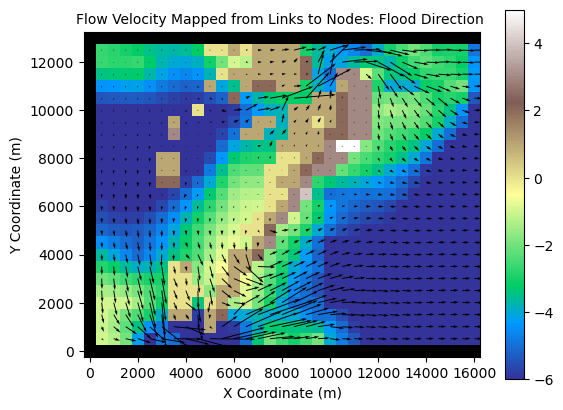

In [15]:
# test plot
# Plot using matplotlib quiver
grid.imshow("topographic__elevation", cmap="terrain", vmin=-6) # vmin may need to be less than 0 if bathymetric data is loaded
plt.quiver(node_x, node_y, vel_x, vel_y)
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.title(f"Flow Velocity Mapped from Links to Nodes: {title_ID} Direction ", fontsize = 10)
plt.show()

## Ebb-Tide

In [16]:
# save the velocity information
ebb_vel_link = grid.at_link["ebb_tide_flow__velocity"]

In [17]:
# map links and nodes
ebb_vel_x, ebb_vel_y = map_link_vector_components_to_node(grid, ebb_vel_link)

In [18]:
# Get node coordinates
ebb_node_x = grid.node_x
ebb_node_y = grid.node_y

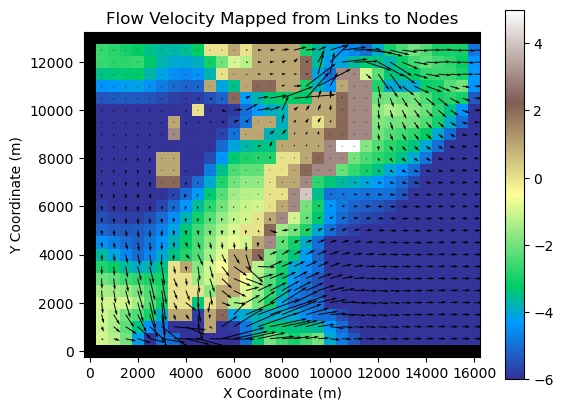

In [19]:
# test plot
# Plot using matplotlib quiver
grid.imshow("topographic__elevation", cmap="terrain", vmin=-6) # vmin may need to be less than 0 if bathymetric data is loaded
plt.quiver(ebb_node_x, ebb_node_y, ebb_vel_x, ebb_vel_y)
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.title("Flow Velocity Mapped from Links to Nodes")
plt.show()

## Flood-Tide

In [20]:
# save the flood velocity information
from landlab.grid.mappers import map_link_vector_components_to_node
flood_vel_link = grid.at_link["flood_tide_flow__velocity"]

In [21]:
# map links and nodes
flood_vel_x, flood_vel_y = map_link_vector_components_to_node(grid, flood_vel_link)

In [22]:
# get node coordinates
flood_node_x = grid.node_x
flood_node_y = grid.node_y

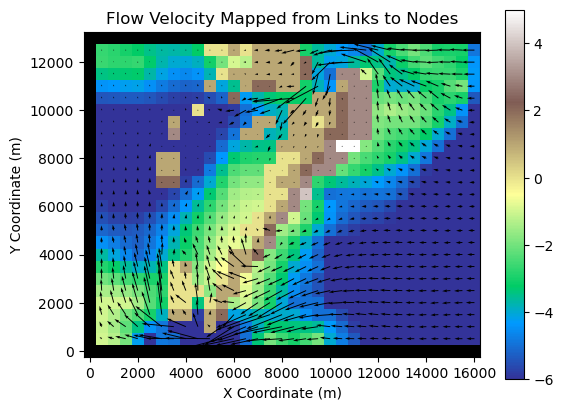

In [23]:
# test plot using quiver
grid.imshow("topographic__elevation", cmap="terrain", vmin=-6)
plt.quiver(flood_node_x, flood_node_y, flood_vel_x, flood_vel_y)
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.title("Flow Velocity Mapped from Links to Nodes")
plt.show()